# 01. Find optimized threshold using PLCO cohort

## 01-1. Sensitivy analysis to find concentration distinguish case (MM prog. & MGUS non-prog.) and controls (healthy) in PLCO

In [1]:
import pandas as pd
import numpy as np
import os, glob, subprocess, itertools
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
import warnings
warnings.filterwarnings('ignore')
from matplotlib.ticker import FixedLocator, FuncFormatter
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

isotype_order = ['IgG', 'IgA', 'IgM']
thresholds = {'IgG': 0.359, 'IgA': 0.325, 'IgM': 0.197}
palette = {'IgG': '#66c2a5', 'IgA': '#fc8d62', 'IgM': '#8da0cb'}

################################## Prepare data ##################################

############## Controls
df = pd.read_csv('../data/PLCO_ms_healthy.csv', sep=",")

#### Set age
df['Age_At_Sample'] = df['age'] + (df['sample_drawdays']/365)

#### remove 'control' for MS run
df = df.dropna(subset=['plco_id'])

#### Those without hematopietic cancer
df = df[df['j_hema_cancer'] == 0]

#### Per clone (LATER)
ms_names = ['Type', 'm/z', 'Conc', 'Flag']
identifier_cols = [col for col in df.columns if not any(col.startswith(f"{n}_") for n in ms_names)]

reshaped = pd.wide_to_long(
    df, 
    stubnames=ms_names, 
    i=identifier_cols, 
    j='Sample_Nmber', 
    sep='_', 
    suffix='\d+'
).reset_index()

reshaped = reshaped.dropna(subset=['Type', 'Conc'], how='all')

reshaped['Conc'] = reshaped['Conc'].replace({"Present" : 0})
reshaped['Type_heavy'] = reshaped['Type'].str.split('_').str[0]

reshaped['Type_heavy'] = reshaped['Type_heavy'].astype(str) 
reshaped['Conc'] = pd.to_numeric(reshaped['Conc'], errors='coerce')

reshaped['log_Conc'] = np.log10(reshaped['Conc'])

#display(reshaped)

### Those with m.z positive
has_mz = (reshaped['m/z'].notna()) & (reshaped['Conc'].notna()) & (reshaped['Type'] != 'Lambda') & (reshaped['Type'] != 'Kappa')
df_mz_present = reshaped[has_mz].copy()    

### remove kappa and lambda
df_mz_present = df_mz_present[df_mz_present['Type_heavy'].isin(['IgG', 'IgA', 'IgM'])]

### Age clean
def clean_age(age_val):
    if pd.isna(age_val):
        return np.nan
    else:
        return int(age_val)

df_mz_present['Age_clean'] = df_mz_present['Age_At_Sample'].apply(clean_age)

############## Cases
filt_reshaped2 = pd.read_csv('../data/PLCO_ms_clone.csv', sep=",")

## remove <llmi and artifact
#filt_reshaped2 = filt_reshaped2[~filt_reshaped2['Flag_1'].isin(['<LLMI', 'C1q-C', 'MSL', 'MSL-Query'])]

def clean_age(age_val):
    if pd.isna(age_val):
        return np.nan
    else:
        return int(age_val)

filt_reshaped2['Age_clean'] = filt_reshaped2['Age_Sample'].apply(clean_age)

############# Numbers
### positive vs negative 
total_clones = len(reshaped)
## m/z and concentration present & no LC only
mz_present_count = has_mz.sum()
mz_absent_count = total_clones - mz_present_count

pos_df = reshaped[has_mz]
n_pos_samples = pos_df['plco_id'].nunique()
total_samples = reshaped['plco_id'].nunique()
n_neg_samples = total_samples - n_pos_samples

total_samples_case = filt_reshaped2['e_2021_1015_id'].nunique()
total_clones_case = filt_reshaped2['Clone_ID'].nunique()

print(f"PLCO Controls: Total N participant = {total_samples} (MS positive = {n_pos_samples}, No. of clone = {mz_present_count})")
print(f"PLCO Cases : Total N participant = {total_samples_case}, No. of clone = {total_clones_case}")

################################## Finding cutoff (Sensitivy analysis, ROC, bootstraping) ##################################
def find_best_threshold_bruteforce(df, isotype, llmi=0.015, thresholds=None):
    upper = thresholds.get(isotype, np.nan)

    sub = df[
        (df['Type_heavy'] == isotype) &
        (df['Conc_use'] >= llmi) &
        (df['Conc_use'] < upper)
    ].copy()

    n_case = (sub['group'] == 1).sum()
    n_control = (sub['group'] == 0).sum()

    if sub.empty or n_case == 0 or n_control == 0:
        return None

    #candidates = np.sort(sub['Conc_use'].dropna().unique())
    #candidates = np.linspace(llmi, upper, num=2000)
    candidates = np.logspace(np.log10(llmi), np.log10(upper), num=1000)

    best = None
    best_j = -np.inf

    for cutoff in candidates:
        pred_case = sub['Conc_use'] >= cutoff

        tp = ((sub['group'] == 1) & pred_case).sum()
        fn = ((sub['group'] == 1) & (~pred_case)).sum()
        tn = ((sub['group'] == 0) & (~pred_case)).sum()
        fp = ((sub['group'] == 0) & pred_case).sum()

        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        j = sens + spec - 1

        if j > best_j * 1.0001: #### if current J has very little difference with the maximum, choose lower cutoff
            best_j = j
            best = {
                'Type_heavy': isotype,
                'best_threshold': cutoff,
                'sensitivity': sens,
                'specificity': spec,
                'youden_j': j,
                'n_total': len(sub),
                'n_case': int(n_case),
                'n_control': int(n_control),
            }

    return best

def bootstrap_best_threshold_ci(
    df,
    isotype,
    llmi=0.015,
    thresholds=None,
    n_boot=100,
    ci=95,
    random_state=1
):
    rng = np.random.default_rng(random_state)

    upper = thresholds.get(isotype, np.nan)
    sub = df[
        (df['Type_heavy'] == isotype) &
        (df['Conc_use'] >= llmi) &
        (df['Conc_use'] < upper)
    ].copy()

    case_df = sub[sub['group'] == 1].copy()
    ctrl_df = sub[sub['group'] == 0].copy()

    if len(case_df) == 0 or len(ctrl_df) == 0:
        return None

    boot_thresholds = []
    boot_j = []

    for _ in range(n_boot):
        case_boot = case_df.sample(n=len(case_df), replace=True, random_state=rng.integers(1e9))
        ctrl_boot = ctrl_df.sample(n=len(ctrl_df), replace=True, random_state=rng.integers(1e9))
        boot_df = pd.concat([case_boot, ctrl_boot], ignore_index=True)

        res = find_best_threshold_bruteforce(
            boot_df,
            isotype=isotype,
            llmi=llmi,
            thresholds=thresholds
        )

        if res is not None and pd.notna(res['best_threshold']):
            boot_thresholds.append(res['best_threshold'])
            boot_j.append(res['youden_j'])

    if len(boot_thresholds) == 0:
        return None

    alpha = (100 - ci) / 2
    lo = np.percentile(boot_thresholds, alpha)
    hi = np.percentile(boot_thresholds, 100 - alpha)

    point = find_best_threshold_bruteforce(
        sub,
        isotype=isotype,
        llmi=llmi,
        thresholds=thresholds
    )

    out = {
        'Type_heavy': isotype,
        'point_threshold': point['best_threshold'],
        'threshold_ci_lower': lo,
        'threshold_ci_upper': hi,
        'ci_level': ci,
        'n_boot_valid': len(boot_thresholds),
        'median_boot_threshold': np.median(boot_thresholds),
        'boot_threshold_sd': np.std(boot_thresholds, ddof=1),
        'point_sensitivity': point['sensitivity'],
        'point_specificity': point['specificity'],
        'point_youden_j': point['youden_j'],
        'boot_thresholds': np.array(boot_thresholds),
        'boot_js': np.array(boot_j)
    }
    return out

##### Prepare inputs for defining lower limit (case vs control)
print("************************** Finding optimal threshold to distinguish cases vs controls **************************")

LLMI = 0.015

# control
control_df = df_mz_present.copy()
control_df = control_df.rename(columns={'Conc': 'Conc_use'})
control_df['group'] = 0   # control

# case
case_df = filt_reshaped2.copy()
case_df = case_df.rename(columns={'Conc_1': 'Conc_use'})
case_df['group'] = 1      # case

# select columns
common_cols = ['Type_heavy', 'Conc_use', 'group', 'Age_clean']
combined_df = pd.concat(
    [
        control_df[common_cols],
        case_df[common_cols]
    ],
    ignore_index=True
)

combined_df = combined_df.dropna(subset=['Type_heavy', 'Conc_use']).copy()
combined_df = combined_df[combined_df['Type_heavy'].isin(isotype_order)].copy()

boot_ci_results = {}

for age_cutoff in ['total', '<60', '>=60']:
    if age_cutoff == 'total':
        input_df = combined_df.copy()
    elif age_cutoff == '<60':
        input_df = combined_df[combined_df['Age_clean'] < 60]
    elif age_cutoff == '>=60':
        input_df = combined_df[combined_df['Age_clean'] >= 60]
    
    print(age_cutoff)
    
    boot_results = []
    boot_raw = {}

    for iso in isotype_order:
        out = bootstrap_best_threshold_ci(
            input_df,
            isotype=iso,
            llmi=0.015,
            thresholds=thresholds,
            n_boot=100,
            ci=95,
            random_state=42
        )
        if out is not None:
            boot_raw[iso] = out
            boot_results.append({
                'Type_heavy': out['Type_heavy'],
                'Best_threshold': out['point_threshold'],
                'CI_lower': out['threshold_ci_lower'],
                'CI_upper': out['threshold_ci_upper'],
                'Sensitivity': out['point_sensitivity'],
                'Specificity': out['point_specificity'],
                'Youden_J': out['point_youden_j'],
                'Boot_SD': out['boot_threshold_sd'],
                'n_boot_valid': out['n_boot_valid']
            })

    boot_ci_df = pd.DataFrame(boot_results)
    display(boot_ci_df.round(4))
    
    boot_ci_results[age_cutoff] = boot_ci_df.copy()


#### Use 'total'
boot_ci_total = boot_ci_results['total'].copy()

best_thr_map = dict(zip(boot_ci_total['Type_heavy'], boot_ci_total['Best_threshold']))
ci_lower_map = dict(zip(boot_ci_total['Type_heavy'], boot_ci_total['CI_lower']))
ci_upper_map = dict(zip(boot_ci_total['Type_heavy'], boot_ci_total['CI_upper']))

print(best_thr_map)
print(ci_lower_map)
print(ci_upper_map)


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


PLCO Controls: Total N participant = 778 (MS positive = 661, No. of clone = 1224)
PLCO Cases : Total N participant = 491, No. of clone = 1885
************************** Finding optimal threshold to distinguish cases vs controls **************************
total


,Type_heavy,Best_threshold,CI_lower,CI_upper,Sensitivity,Specificity,Youden_J,Boot_SD,n_boot_valid
0,IgG,0.1262,0.1180,0.3545,0.7816,0.2381,0.0197,0.0848,100
1,IgA,0.0881,0.0709,0.1191,0.2467,0.8671,0.1137,0.0148,100
2,IgM,0.0441,0.0371,0.0870,0.4121,0.6702,0.0823,0.0126,100


<60


,Type_heavy,Best_threshold,CI_lower,CI_upper,Sensitivity,Specificity,Youden_J,Boot_SD,n_boot_valid
0,IgG,0.2731,0.1113,0.3390,0.2683,0.9375,0.2058,0.0404,100
1,IgA,0.1113,0.0220,0.2588,0.1231,0.9348,0.0579,0.0675,100
2,IgM,0.0972,0.0150,0.1782,0.1180,0.8956,0.0136,0.0556,100


>=60


,Type_heavy,Best_threshold,CI_lower,CI_upper,Sensitivity,Specificity,Youden_J,Boot_SD,n_boot_valid
0,IgG,0.1632,0.1151,0.3545,0.6193,0.4182,0.0375,0.0818,100
1,IgA,0.0881,0.0552,0.1191,0.2576,0.8819,0.1395,0.0160,100
2,IgM,0.0441,0.0390,0.0799,0.4269,0.6853,0.1122,0.0098,100


{'IgG': 0.126167719452276, 'IgA': 0.08809283100628428, 'IgM': 0.04405953851559696}
{'IgG': 0.11802124671685307, 'IgA': 0.07092648292794464, 'IgM': 0.03707095848732717}
{'IgG': 0.35446463683118296, 'IgA': 0.11911850430574301, 'IgM': 0.0870134687306597}


## 01-2. Persistence probability

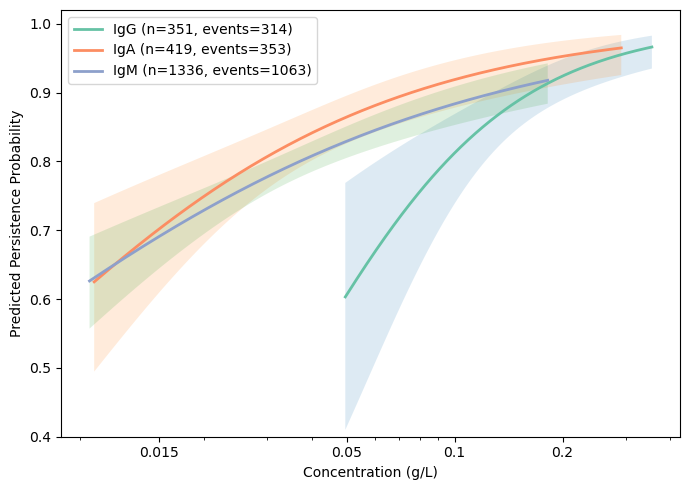

,isotype,n,events,coef_intercept,coef_slope,pval_slope,use_log_conc,prob_cut,threshold_conc
0,IgA,419,353,4.334168,0.828120,5.129765e-06,True,None,NaN
1,IgG,351,314,4.896603,1.490507,8.184861e-06,True,None,NaN
2,IgM,1336,1063,3.511469,0.644538,1.245935e-09,True,None,NaN


,isotype,best_thr,ci_lower_thr,ci_upper_thr,best_prob,prob_at_ci_lower_thr,prob_at_ci_upper_thr
0,IgG,0.126,0.118,0.354,86,85,97
1,IgA,0.088,0.071,0.119,91,90,93
2,IgM,0.044,0.037,0.088,82,80,87


Min concentration: 0.045
5th percentile: 0.07885144499999999
Number <0.05: 4
Total below BS threshold 2106
MGIP: lower limit =< x < 0.2 832
MGIP: x>=0.2 187
MGIP: x<0.2 1919


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from scipy.special import expit


########################### Prepare input (interval) ###########################
def make_intervals(df,
                   person_col=None,
                   clone_col=None,
                   time_col=None,
                   conc_col=None,
                   min_gap=None,
                   time_ascending=None):
    d = df.copy()

    d[conc_col] = pd.to_numeric(d[conc_col], errors='coerce')
    d["_detected"] = d[conc_col].fillna(0) > 0

    # timeline per patient
    if time_ascending:
        patient_timeline = (
            d.groupby(person_col)[time_col]
             .unique()
             .apply(lambda x: sorted(x))
             .to_dict()
        )
    else:
        patient_timeline = (
            d.groupby(person_col)[time_col]
             .unique()
             .apply(lambda x: sorted(x, reverse=True))
             .to_dict()
        )

    # (person, time, clone) existence
    present_keys = set(
        d.loc[d[clone_col].notna(), [person_col, time_col, clone_col]]
         .itertuples(index=False, name=None)
    )

    # conc lookup
    conc_map = (
        d.loc[d[clone_col].notna(), [person_col, time_col, clone_col, conc_col]]
         .drop_duplicates([person_col, time_col, clone_col])
         .set_index([person_col, time_col, clone_col])[conc_col]
         .to_dict()
    )

    next_time_list = []
    next_detected_list = []
    next_conc_list = []

    for _, row in d.iterrows():
        pid = row[person_col]
        t = row[time_col]
        cl = row[clone_col]

        if pd.isna(cl):
            next_time_list.append(np.nan)
            next_detected_list.append(False)
            next_conc_list.append(np.nan)
            continue

        timeline = patient_timeline.get(pid, [])
        if t not in timeline:
            next_time_list.append(np.nan)
            next_detected_list.append(False)
            next_conc_list.append(np.nan)
            continue

        idx = timeline.index(t)

        found_time = np.nan
        found_detected = False
        found_conc = np.nan

        # search by timepoint order
        for future_t in timeline[idx + 1:]:
            key = (pid, future_t, cl)
            if key in present_keys:
                found_time = future_t
                found_detected = True
                found_conc = conc_map.get(key, np.nan)
                break

        next_time_list.append(found_time)
        next_detected_list.append(found_detected)
        next_conc_list.append(found_conc)

    d["next_time"] = next_time_list
    d["next_detected"] = next_detected_list
    d["next_conc"] = next_conc_list
    d["y_persist"] = d["next_detected"].astype(int)

    ## remove last sample
    d = d[d[time_col] != d.groupby(person_col)[time_col].transform('max' if time_ascending else 'min')].copy()    
    
    return d

########################### Spline model (y= bs(conc) + age + isotype) ###########################
import statsmodels.formula.api as smf
from patsy import bs
import matplotlib.pyplot as plt

def spline_logistic_regression_model(input_df, outcome_col=None, spline_df=4, prob_cut=0.95, ref_isotype="IgM"):
    # 1) fit
    formula = (
        f"{outcome_col} ~ "
        f"bs(conc_t_log10, df={spline_df}, include_intercept=False) "
        f"+ age + C(Type_heavy)"
    )
    model = smf.logit(formula, data=input_df)
    res = model.fit(disp=0)

    # 2) grid for prediction (use input_df, not external 'intervals')
    x = np.linspace(input_df["conc_t_log10"].min(), input_df["conc_t_log10"].max(), 200)

    pred_df = pd.DataFrame({
        "conc_t_log10": x,
        "age": float(np.nanmedian(input_df["age"])),
        "Type_heavy": ref_isotype
    })

    # 3) predict probability
    p = res.predict(pred_df)

    # 4) plot
    plt.figure(figsize=(6.5, 4.8))
    plt.plot(10**x, p)
    plt.xscale("log")
    custom_ticks = [0.015, 0.05, 0.1, 0.2]
    plt.xticks(custom_ticks, labels=[str(t) for t in custom_ticks])
    plt.ylim(-0.02, 1.02)
    plt.xlabel("Concentration (g/L)")
    plt.ylabel("Probability")
    plt.show()

    # 5) 
    
    # 6) threshold where prob crosses prob_cut
    idx = np.where(p >= prob_cut)[0]
    if len(idx) == 0:
        print(f"No threshold found where predicted prob >= {prob_cut} within observed range.")
        return res, None

    thr_raw = float(10 ** x[idx[0]])
    print(f"Threshold (first conc where P>= {prob_cut}): {thr_raw:.4g}")



def spline_logistic_regression_model_isotype(df,
                                 outcome_col=None,
                                 spline_df=4,
                                 prob_cut=None,
                                 min_events=10,
                                 alpha=1.0,
                                 grid_n=300,
                                 x_ticks=(0.015, 0.05, 0.1, 0.2),
                                 figsize=(7,5)):

    plt.figure(figsize=figsize)

    for iso in sorted(df["Type_heavy"].dropna().unique()):

        df_iso = df[df["Type_heavy"] == iso].copy()

        formula = (
            f"{outcome_col} ~ "
            f"bs(conc_t_log10, df={spline_df}, include_intercept=False) "
            f"+ age"
        )

        res, (n0, n1), fit_status = safe_logit_fit(
            formula, df_iso, min_events=min_events, alpha=alpha
        )

        if res is None:
            print(f"[{iso}] skipped (fit={fit_status}, n0={n0}, n1={n1})")
            continue

        # grid 
        x = np.linspace(df_iso["conc_t_log10"].min(),
                        df_iso["conc_t_log10"].max(),
                        grid_n)

        pred_df = pd.DataFrame({
            "conc_t_log10": x,
            "age": float(np.nanmedian(df_iso["age"]))
        })

        p = np.asarray(res.predict(pred_df), dtype=float)
        conc_raw = 10**x

        plt.plot(conc_raw, p, label=f"{iso} ({fit_status})")

        # threshold 
        if prob_cut is not None:
            idx = np.where(p >= prob_cut)[0]
            if len(idx) > 0:
                thr = conc_raw[idx[0]]
                plt.axvline(thr, linestyle="--", alpha=0.5)
                print(f"[{iso}] Threshold @ P≥{prob_cut}: {thr:.4g}")

    plt.xscale("log")
    plt.ylim(-0.02, 1.02)
    plt.xticks(list(x_ticks), [str(t) for t in x_ticks])
    plt.xlabel("Concentration (g/L)")
    plt.ylabel(f"P({outcome_col}=1)")
    plt.legend(title="Type_heavy")
    plt.tight_layout()
    plt.show()


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.special import expit

def logistic_glm_model_isotype(
    df,
    conc_col="Conc_1",
    outcome_col="y_persist",
    isotype_col="Type_heavy",
    isotypes=None,
    use_log_conc=True,          # True: log(conc) 
    prob_cut=None,              
    min_events=10,
    min_total=30,
    grid_n=300,
    xscale_log=True,
    x_ticks=(0.015, 0.05, 0.1, 0.2),
    xlim=None,                  # None: 1~99% quantile
    ylim=(0.6, 1.02),
    figsize=(7, 5),
    show_scatter=False,
    scatter_alpha=0.12,
    robust_se=True,             # HC1 robust
    llmi=0.1, #0.015
    save_fig=None,
):
    """
    Isotype-specific GLM(Binomial) logistic regression:
      logit(P(outcome=1)) = b0 + b1 * log(conc)  (use_log_conc=True)
                         or b0 + b1 * conc      (use_log_conc=False)

    Plot predicted probability curve + 95% CI band, and optional threshold.
    Returns a summary table per isotype.
    """
    d0 = df[[conc_col, outcome_col, isotype_col]].dropna().copy()
    d0[conc_col] = pd.to_numeric(d0[conc_col], errors="coerce")
    d0[outcome_col] = pd.to_numeric(d0[outcome_col], errors="coerce").astype(int)
    d0[isotype_col] = d0[isotype_col].astype(str)
    d0 = d0.dropna(subset=[conc_col])
    d0 = d0[d0[conc_col] > 0].copy()

    isotype_order = ['IgG', 'IgA', 'IgM']
    palette = {'IgG': '#66c2a5', 'IgA': '#fc8d62', 'IgM': '#8da0cb'}
    
    if isotypes is None:
        isotypes = sorted(d0[isotype_col].unique())

    plt.figure(figsize=figsize)
    rows = []
    models = {}

    for iso in isotype_order:
        di = d0[d0[isotype_col] == str(iso)].copy()
        n = len(di)
        k = int(di[outcome_col].sum())

        if n < min_total:
            print(f"[skip] {iso}: too few rows (n={n} < {min_total})")
            continue
        if k < min_events:
            print(f"[skip] {iso}: too few events (events={k} < {min_events})")
            continue

        # add transformed conc
        if use_log_conc:
            di["_x"] = np.log(di[conc_col].astype(float))
            formula = f"{outcome_col} ~ _x"
        else:
            di["_x"] = di[conc_col].astype(float)
            formula = f"{outcome_col} ~ _x"

        # fit GLM binomial (robust cov optional)
        m = smf.glm(formula, data=di, family=sm.families.Binomial())
        res = m.fit(cov_type="HC1") if robust_se else m.fit()
        models[iso] = res
        
        b0 = float(res.params["Intercept"])
        b1 = float(res.params["_x"])
        pval1 = float(res.pvalues["_x"])

        # grid on concentration scale
        if xlim is None:
            xmin = float(np.nanquantile(di[conc_col], 0.01))
            xmax = float(np.nanquantile(di[conc_col], 0.99))
        else:
            xmin, xmax = xlim

        if xscale_log:
            xmin = max(xmin, 1e-12)
            xmax = max(xmax, xmin * 1.001)
            grid_c = np.geomspace(xmin, xmax, grid_n)
        else:
            grid_c = np.linspace(xmin, xmax, grid_n)

        grid_x = np.log(grid_c) if use_log_conc else grid_c
        new = pd.DataFrame({"_x": grid_x})

        # prediction on mean scale (probability) with CI
        sf = res.get_prediction(new).summary_frame(alpha=0.05)
        # statsmodels GLM summary_frame columns: mean, mean_ci_lower, mean_ci_upper
        p_hat = sf["mean"].to_numpy(dtype=float)
        lo = sf["mean_ci_lower"].to_numpy(dtype=float)
        hi = sf["mean_ci_upper"].to_numpy(dtype=float)

        if show_scatter:
            plt.scatter(di[conc_col].values, di[outcome_col].values, s=10, alpha=scatter_alpha)

        plt.plot(grid_c, p_hat, linewidth=2.0, label=f"{iso} (n={n}, events={k})", color = palette[iso])
        plt.fill_between(grid_c, lo, hi, alpha=0.15)

        # threshold for P >= prob_cut
        thr = np.nan
        if prob_cut is not None and b1 > 0:
            logit_p = np.log(prob_cut / (1 - prob_cut))
            if use_log_conc:
                thr = float(np.exp((logit_p - b0) / b1))
            else:
                thr = float((logit_p - b0) / b1)

            plt.axhline(prob_cut, linestyle="--", alpha=0.25)
            #plt.axvline(llmi, linestyle="--", alpha=0.25)
            
#             if np.isfinite(thr) and (thr >= grid_c.min()) and (thr <= grid_c.max()):
#                 plt.axvline(thr, linestyle="--", alpha=0.25)

        rows.append({
            "isotype": iso,
            "n": n,
            "events": k,
            "coef_intercept": b0,
            "coef_slope": b1,
            "pval_slope": pval1,
            "use_log_conc": use_log_conc,
            "prob_cut": prob_cut,
            "threshold_conc": thr,
        })

    if xscale_log:
        plt.xscale("log")
        if x_ticks is not None:
            plt.xticks(list(x_ticks), [str(t) for t in x_ticks])

    plt.ylim(*ylim)
    plt.xlabel("Concentration (g/L)")
    plt.ylabel(f"Predicted Persistence Probability")
    plt.legend()
    plt.tight_layout()
    if save_fig:
        plt.savefig(save_fig, bbox_inches='tight')
    plt.show()

    summary = pd.DataFrame(rows).sort_values("isotype").reset_index(drop=True)
    return summary, models

def predict_prob_from_models(models, conc_map, use_log_conc=True, alpha=0.05):
    rows = []

    for iso, conc in conc_map.items():
        if iso not in models:
            rows.append({
                "isotype": iso,
                "conc": conc,
                "pred_prob": np.nan,
                "ci_lower": np.nan,
                "ci_upper": np.nan,
            })
            continue

        res = models[iso]
        x = np.log(conc) if use_log_conc else conc
        new = pd.DataFrame({"_x": [x]})

        sf = res.get_prediction(new).summary_frame(alpha=alpha)

        rows.append({
            "isotype": iso,
            "conc": conc,
            "pred_prob": int(round(sf["mean"].iloc[0] * 100)), 
            "ci_lower": int(round(sf["mean_ci_lower"].iloc[0] * 100)),
            "ci_upper": int(round(sf["mean_ci_upper"].iloc[0] * 100)),
        })

    return pd.DataFrame(rows).sort_values("isotype").reset_index(drop=True)

################################### Running ###########################
df_ori = pd.read_csv('../data/PLCO_ms_clone.csv', sep=",")

remove_mask = (
    (df_ori['Conc_1'].isna()) |
    (df_ori['Conc_1'] == 0) |
    (df_ori['Flag_1'].isin(['<LLMI', 'MSL', 'C1q-C'])) |
    (df_ori['Type_1'].isin(['Kappa', 'Lambda']))
)

df_input = df_ori.loc[~remove_mask].copy()

#display(df_input[['e_2021_1015_id', 'Clone_ID', 'Yr_before_dx', 'Conc_1']])

# 0) create interval 
intervals = make_intervals(
    df_input,
    person_col="e_2021_1015_id",
    clone_col="Clone_ID",
    time_col="Yr_before_dx",
    conc_col="Conc_1",
    min_gap=1,          # 1 year gap (at least) 
    time_ascending=False,
)

#display(intervals[['e_2021_1015_id', 'Clone_ID', 'Yr_before_dx', 'Conc_1', 'y_persist', 'y_increase']])

# BS threshold 
thresholds = {'IgG': 0.359, 'IgA': 0.325, 'IgM': 0.197}

def is_below_threshold(row):
    h_type = str(row['Type_heavy'])
    conc = row['Conc_1']

    limit = next((v for k, v in thresholds.items() if k in h_type), None)
    
    if limit is not None:
        return conc < limit
    return False

mgip_df = intervals[intervals.apply(is_below_threshold, axis=1)].copy()

######## Persistence

summary, models = logistic_glm_model_isotype(
    mgip_df,
    conc_col="Conc_1",
    outcome_col="y_persist",
    isotype_col="Type_heavy",
    prob_cut=None,     
    min_events=10,
    grid_n=300,
    x_ticks=(0.015, 0.05, 0.1, 0.2),
    ylim=(0.4, 1.02),
    figsize=(7,5),
    show_scatter=False,
    llmi=0.05,
    save_fig=f'../00.Figures/Persistence_Prob_PLCO_cases.pdf'
)

display(summary)


######### Get probability at estimated values
best_thr_map = {'IgG': 0.126, 'IgA': 0.088, 'IgM': 0.044}
ci_lower_map = {'IgG': 0.118, 'IgA': 0.071, 'IgM': 0.037}
ci_upper_map = {'IgG': 0.354, 'IgA': 0.119, 'IgM': 0.088}

best_prob_df = predict_prob_from_models(models, best_thr_map, use_log_conc=True)
lower_prob_df = predict_prob_from_models(models, ci_lower_map, use_log_conc=True)
upper_prob_df = predict_prob_from_models(models, ci_upper_map, use_log_conc=True)

best_prob_df = best_prob_df.rename(columns={
    "conc": "best_thr",
    "pred_prob": "best_prob",
    "ci_lower": "best_prob_ci_lower",
    "ci_upper": "best_prob_ci_upper",
})

lower_prob_df = lower_prob_df.rename(columns={
    "conc": "ci_lower_thr",
    "pred_prob": "prob_at_ci_lower_thr",
    "ci_lower": "prob_at_ci_lower_thr_ci_lower",
    "ci_upper": "prob_at_ci_lower_thr_ci_upper",
})

upper_prob_df = upper_prob_df.rename(columns={
    "conc": "ci_upper_thr",
    "pred_prob": "prob_at_ci_upper_thr",
    "ci_lower": "prob_at_ci_upper_thr_ci_lower",
    "ci_upper": "prob_at_ci_upper_thr_ci_upper",
})

prob_table = (
    best_prob_df
    .merge(lower_prob_df, on="isotype", how="outer")
    .merge(upper_prob_df, on="isotype", how="outer")
)

simple_prob_table = pd.DataFrame({
    "isotype": list(best_thr_map.keys()),
    "best_thr": [best_thr_map[k] for k in best_thr_map],
    "ci_lower_thr": [ci_lower_map[k] for k in ci_lower_map],
    "ci_upper_thr": [ci_upper_map[k] for k in ci_upper_map],
}).merge(
    best_prob_df[["isotype", "best_prob"]],
    on="isotype",
    how="left"
).merge(
    lower_prob_df[["isotype", "prob_at_ci_lower_thr"]],
    on="isotype",
    how="left"
).merge(
    upper_prob_df[["isotype", "prob_at_ci_upper_thr"]],
    on="isotype",
    how="left"
)

display(simple_prob_table)


### IgG concentration distribution
df_igg = mgip_df[mgip_df["Type_heavy"] == "IgG"]

print("Min concentration:", df_igg["Conc_1"].min())
print("5th percentile:", df_igg["Conc_1"].quantile(0.05))
print("Number <0.05:", (df_igg["Conc_1"] < 0.05).sum())


#### How many new MGIPs
llmi_dict = {
    'IgG': 0.0,
    'IgA': 0.070,
    'IgM': 0.044
}

mgip_df = mgip_df.copy()

mgip_df['llmi'] = mgip_df['Type_heavy'].map(llmi_dict)

mgip_df_1 = mgip_df[
    (mgip_df['Conc_1'] >= mgip_df['llmi']) &
    (mgip_df['Conc_1'] < 0.2)
]

mgip_df_2 = mgip_df[
    mgip_df['Conc_1'] >= 0.2
]

mgip_df_3 = mgip_df[
    mgip_df['Conc_1'] < 0.2
]

print('Total below BS threshold', len(mgip_df))
print('MGIP: lower limit =< x < 0.2', len(mgip_df_1))
print('MGIP: x>=0.2', len(mgip_df_2))
print('MGIP: x<0.2', len(mgip_df_3))

## 01-3. Cox hazard analysis (exceeding MGUS threshold)

            count  sum      mean
Type_heavy                      
IgA           193   11  0.056995
IgG            91   22  0.241758
IgM           708   28  0.039548
              n  n_ge_y  frac_ge_y
Type_heavy                        
IgA         193      70   0.362694
IgG          91      25   0.274725
IgM         708     212   0.299435
              n  n_ge_y  frac_ge_y
Type_heavy                        
IgA         193      11   0.056995
IgG          91       1   0.010989
IgM         708      30   0.042373


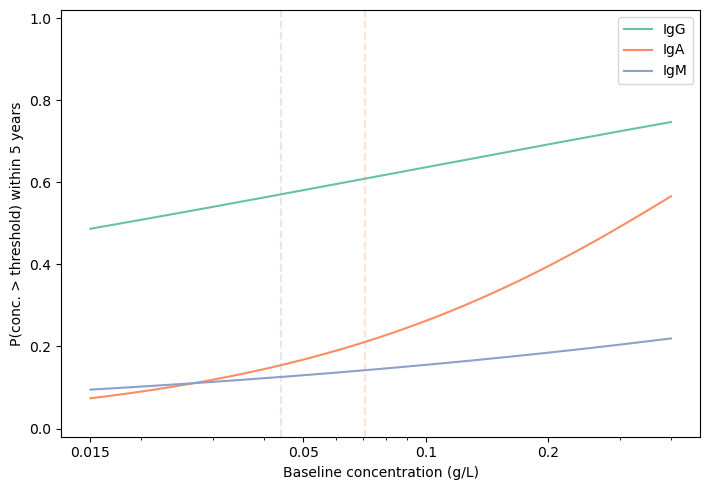

,Type_heavy,y_years,given_value_g_per_L,prob_at_given_value
0,IgG,5,NaN,NaN
1,IgA,5,0.071,0.211
2,IgM,5,0.044,0.126


In [3]:
################################### Cox model for exceeding MGUS threshold ###########################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from patsy import dmatrix
from lifelines import CoxPHFitter
import statsmodels.formula.api as smf
from patsy import bs
from scipy.interpolate import interp1d

import numpy as np
import pandas as pd

def make_time_to_cross_df(
    df,
    person_col="e_2021_1015_id",
    clone_col="Clone_ID",
    time_col="Yr_before_dx",   
    conc_col="Conc_1",
    iso_col="Type_heavy",
    age_col="age",
    cross_level=0.2, ## when fixed
    threshold_mode='fixed', # 'fixed' (0.2g/L) or 'BS' (Binding Site)
    require_detected_at_baseline=True,  
):
    d = df[[person_col, clone_col, time_col, conc_col, iso_col, age_col]].copy()
    d = d.dropna(subset=[person_col, clone_col, time_col, conc_col, iso_col])
    d[conc_col] = d[conc_col].astype(float)
    d[time_col] = d[time_col].astype(float)

    # sort by time (year before dx)
    d = d.sort_values([person_col, clone_col, time_col], ascending=[True, True, False])

    rows = []
    for (pid, cid), g in d.groupby([person_col, clone_col], sort=False):
        g = g.copy()

        # baseline 
        base = g.iloc[0]
        base_time = float(base[time_col])
        base_conc = float(base[conc_col])
        iso = str(base[iso_col])

        if require_detected_at_baseline and base_conc <= 0:
            continue

        # --- Threshold ---
        if threshold_mode == 'BS':
            if 'IgG' in iso:
                current_thresh = 0.359
            elif 'IgA' in iso:
                current_thresh = 0.325
            elif 'IgM' in iso:
                current_thresh = 0.197
            else:
                current_thresh = cross_level 
        else:
            current_thresh = cross_level 

        age = float(g[age_col].dropna().iloc[0]) if age_col in g and g[age_col].notna().any() else np.nan

        idx_event = g.index[g[conc_col] >= current_thresh].tolist()
        
        if len(idx_event) > 0:
            first_cross_row = g[g[conc_col] >= current_thresh].iloc[0]
            event = 1
            t_years = base_time - float(first_cross_row[time_col])
        else:
            last = g.iloc[-1]
            event = 0
            t_years = base_time - float(last[time_col])

        rows.append({
            person_col: pid,
            clone_col: cid,
            "Type_heavy": iso,
            "age": age,
            "baseline_conc": base_conc,
            "baseline_conc_log10": np.log10(max(base_conc, 1e-12)),
            "t_years": float(t_years),
            "event_cross": int(event),
            "threshold_used": current_thresh 
        })

    out = pd.DataFrame(rows)
    out["t_years"] = out["t_years"].clip(lower=1e-6)
    return out

def fit_linear_cox_by_isotype(
    surv_df,
    iso_col="Type_heavy",
    age_col="age",
    conc_col="baseline_conc_log10",
    time_col="t_years",
    event_col="event_cross",
    spline_df=4,
    penalizer=0.1,
):
    models = {}
    for iso in sorted(surv_df[iso_col].dropna().unique()):
        d = surv_df[surv_df[iso_col] == iso].copy()
        d = d.dropna(subset=[time_col, event_col, conc_col, age_col])

        fit_df = d[[time_col, event_col, conc_col, age_col]].dropna()

        # standardiztaion (z-score)
        for c in [conc_col, age_col]:
            fit_df[c] = (fit_df[c] - fit_df[c].mean()) / fit_df[c].std()

        cph = CoxPHFitter(penalizer=penalizer)
        cph.fit(fit_df, duration_col=time_col, event_col=event_col)

        models[iso] = {"cph": cph,
               "mu_log": float(surv_df["baseline_conc_log10"].mean()),
               "sd_log": float(surv_df["baseline_conc_log10"].std()),
               "mu_age": float(surv_df["age"].mean()),
               "sd_age": float(surv_df["age"].std())}

    return models



def predict_prob_within_y_linear(model, conc_raw_grid, y_horizon, age_value):
    cph = model["cph"]

    # standardize like training (here using model's stored mean/sd)
    logc = np.log10(np.clip(conc_raw_grid, 1e-12, None))
    z_logc = (logc - model["mu_log"]) / model["sd_log"]
    z_age  = (age_value - model["mu_age"]) / model["sd_age"]

    X = pd.DataFrame({"baseline_conc_log10": z_logc, "age": z_age})

    S0 = cph.baseline_survival_
    t0 = S0.index[S0.index.get_indexer([y_horizon], method="nearest")[0]]
    S0_y = float(S0.loc[t0].values[0])

    linpred = X.values @ cph.params_.values
    S_y = S0_y ** np.exp(linpred)
    return 1 - S_y


def plot_prob_curves_linear(models, surv_df, y_horizon=3.0, 
                            prob_cut=None, save_fig=None,
                            llmi=0.015,
                            x_min=0.005, x_max=0.2, x_ticks=(0.015,0.05,0.1,0.2)):
    age_value = float(np.nanmedian(surv_df["age"]))
    conc_grid = np.logspace(np.log10(x_min), np.log10(x_max), 250)

    isotype_order = ['IgG', 'IgA', 'IgM']
    palette = {'IgG': '#66c2a5', 'IgA': '#fc8d62', 'IgM': '#8da0cb'}
    
    plt.figure(figsize=(7.2, 5.0))
    rows = []

    for iso in isotype_order:
        m = models[iso]
        p = predict_prob_within_y_linear(m, conc_grid, y_horizon, age_value)
        plt.plot(conc_grid, p, label=iso, color = palette[iso])
        
        if isinstance(llmi, dict):
            given_val = llmi.get(iso, np.nan)
        else:
            given_val = llmi
        
        ## probability at lower limit (MGIP)
        if pd.notna(given_val):
            p_at_given = float(
                predict_prob_within_y_linear(
                    m, np.array([given_val]), y_horizon, age_value
                )[0]
            )
        else:
            p_at_given = np.nan

        row = {
            "Type_heavy": iso,
            "y_years": y_horizon,
            "given_value_g_per_L": given_val,
            "prob_at_given_value": round(p_at_given, 3) if pd.notna(p_at_given) else np.nan
        }

        if prob_cut is not None:
            idx = np.where(p >= prob_cut)[0]
            thr = np.nan if len(idx) == 0 else float(conc_grid[idx[0]])
            row.update({
                "prob_cut": prob_cut,
                "threshold_g_per_L": thr
            })

        rows.append(row)

        if given_val:
            plt.axvline(given_val, color = palette[iso], linestyle="--", alpha=0.25)


    plt.xscale("log")
    plt.ylim(-0.02, 1.02)
    plt.xticks(list(x_ticks), [str(t) for t in x_ticks])
    if prob_cut:
        plt.axhline(prob_cut, linestyle="--", alpha=0.25)
    plt.xlabel("Baseline concentration (g/L)")
    plt.ylabel(f"P(conc. > threshold) within {y_horizon} years")
    plt.legend()
    plt.tight_layout()
    if save_fig:
        plt.savefig(save_fig, bbox_inches='tight')
    plt.show()

    rows_df = pd.DataFrame(rows)
    display(rows_df)


######################## Cox model RUNNING
df_input = pd.read_csv('../data/PLCO_ms_clone.csv', sep=",")

# 1) create survival table 
surv_df = make_time_to_cross_df(
    df_input,
    person_col="e_2021_1015_id",
    clone_col="Clone_ID",
    time_col="Yr_before_dx",
    conc_col="Conc_1",
    iso_col="Type_heavy",
    age_col="age",
    cross_level=0.2, ## if 'BS', it doesn't affect any
    threshold_mode = 'BS', # 'fixed' or 'BS' --> if fixed, 0.2
    require_detected_at_baseline=True
)

surv_df = surv_df[surv_df['Type_heavy'] != 'Lambda']

mgip_surv_df = surv_df[surv_df['baseline_conc']<0.2]

print(mgip_surv_df.groupby("Type_heavy")["event_cross"].agg(["count","sum","mean"]))


# Sanity check (per isotype, rates of >5 years after baseline)
for y in [3, 5]:
    tmp = mgip_surv_df.copy()

    check = tmp.groupby("Type_heavy")["t_years"].agg(
        n="count",
        n_ge_y=lambda s: int((s >= y).sum()),
        frac_ge_y=lambda s: float((s >= y).mean()),
    )
    print(check)



# 2) Cox+spline fit (per isotype)
models = fit_linear_cox_by_isotype(
    mgip_surv_df,
    iso_col="Type_heavy",
    age_col="age",
    conc_col="baseline_conc", #"baseline_conc_log10",
    time_col="t_years",
    event_col="event_cross",
    spline_df=4, penalizer=0.1
)

# 3) Probability curve (>0.2g/L within x years) 
llmi_dict = {
    #'IgG': 0.0,
    'IgA': 0.071,
    'IgM': 0.044
}


plot_prob_curves_linear(
    models, mgip_surv_df,
    y_horizon=5,
    #prob_cut=0.3,
    x_min=0.015, x_max=0.4, 
    llmi=llmi_dict,
    save_fig=f'../00.Figures/Exceeding_Prob_PLCO_cases.pdf'
)


# 02. Validation using an indepdent healthy cohort

Total N participant = 364
MS positive: N participant = 181, No. of clone = 301
MS negative: N participant = 183

Quartile Statistics (Age bin)


n  L_Whisker      Q1  Median      Q3  U_Whisker     Max
Type Age_Bin                                                           
IgG  <60       14     0.1690  0.2027  0.4361  1.0043     1.0491  8.5000
     60+       31     0.1096  0.1891  0.2817  0.4668     0.8662  4.9300
IgA  <60       12     0.0261  0.0312  0.0455  0.1154     0.0587  2.3200
     60+       25     0.0086  0.0487  0.0769  0.1250     0.2180  1.6100
IgM  <60      131     0.0049  0.0136  0.0237  0.0384     0.0738  0.8290
     60+       88     0.0018  0.0150  0.0208  0.0416     0.0698  0.4158

,Type_heavy,Age_Bin,n,BS_threshold,BS_threshold_percentile,Empirical_best_threshold,Empirical_best_percentile,CI_lower,CI_lower_percentile,CI_upper,CI_upper_percentile
0,IgG,<60,14,0.359,42.9,0.126,0.0,0.118,0.0,0.354,42.9
1,IgG,60+,31,0.359,64.5,0.126,6.5,0.118,6.5,0.354,64.5
2,IgA,<60,12,0.325,83.3,0.088,75.0,0.071,75.0,0.119,75.0
3,IgA,60+,25,0.325,92.0,0.088,60.0,0.071,44.0,0.119,64.0
4,IgM,<60,131,0.197,99.2,0.044,78.6,0.037,73.3,0.088,95.4
5,IgM,60+,88,0.197,96.6,0.044,76.1,0.037,70.5,0.088,92.0


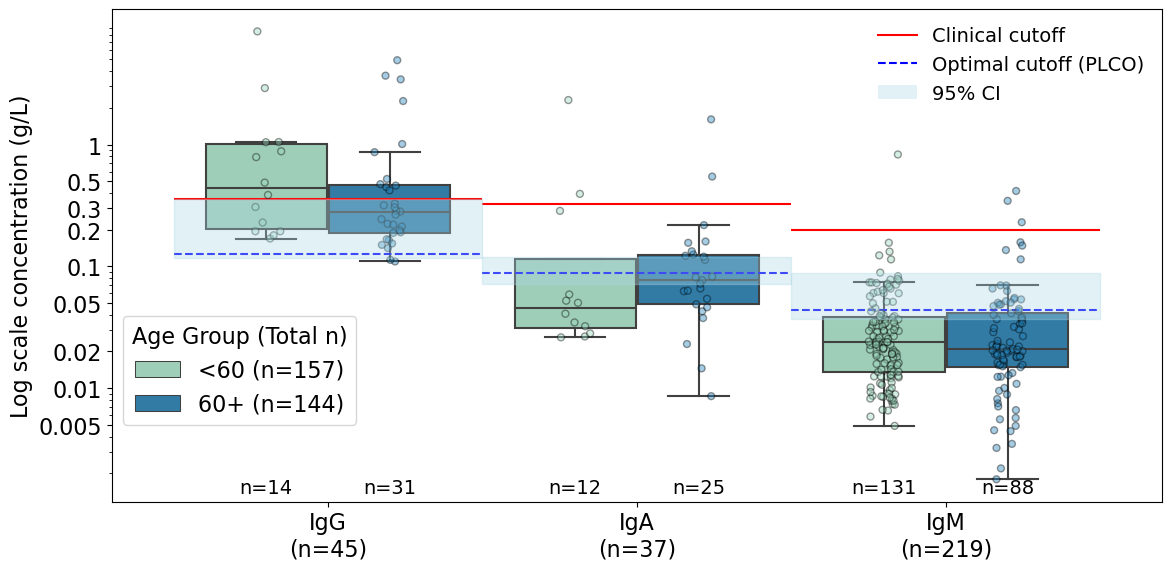

In [4]:
import pandas as pd
import numpy as np
import os, glob, subprocess, itertools
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
import warnings
warnings.filterwarnings('ignore')
from matplotlib.ticker import FixedLocator, FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def percentile_position(series, value):
    series = series.dropna().sort_values()
    pct = (series <= value).sum() / len(series) * 100
    return pct

## from PLCO anlaysis
best_thr_map = {'IgG': 0.126, 'IgA': 0.088, 'IgM': 0.044}
ci_lower_map = {'IgG': 0.118, 'IgA': 0.071, 'IgM': 0.037}
ci_upper_map = {'IgG': 0.354, 'IgA': 0.119, 'IgM': 0.088}


df_name = '../data/external_healthy_ms.csv'

df = pd.read_csv(df_name, sep=",")

drop_cols = [col for col in df.columns if 'Flag 2' in col]
df = df.drop(columns=drop_cols)

drop_patterns = ['Flag Two', 'Flag 2', 'Comments', 'Unnamed']
drop_cols = [col for col in df.columns if any(p in col for p in drop_patterns)]
df = df.drop(columns=drop_cols)

if 'healthy' in df_name:
    df = df.drop_duplicates(subset=['Study ID'], keep='first')
    df['sample_id'] = df['Study ID']
elif 'infection' in df_name:
    df = df.drop_duplicates(subset=['Number '], keep='first')
    df['sample_id'] = df['Number ']

#### Rename
def rename_columns(cols):
    new_cols = []
    for col in cols:
        # Clone 
        if 'Clone' in col:
            num = col.split()[-1]
            new_cols.append(f'Type_{num}')
        # m/z 
        elif 'm/z' in col:
            num = '1' if '.' not in col else str(int(col.split('.')[-1]) + 1)
            new_cols.append(f'm.z_{num}')
        # g/L 
        elif 'g/L' in col and 'EXENT' not in col:
            num = '1' if '.' not in col else str(int(col.split('.')[-1]) + 1)
            new_cols.append(f'Conc_{num}')
        # Flag 
        elif 'Flag' in col:
            num = '1' if '.' not in col else str(int(col.split('.')[-1]) + 1)
            new_cols.append(f'Flag_{num}')
        else:
            new_cols.append(col)
    return new_cols

df.columns = rename_columns(df.columns)

ms_names = ['Type', 'm.z', 'Conc', 'Flag']
identifier_cols = [col for col in df.columns if not any(col.startswith(f"{n}_") for n in ms_names)]

reshaped = pd.wide_to_long(
    df, 
    stubnames=ms_names, 
    i=identifier_cols, 
    j='Clone_Number', 
    sep='_', 
    suffix='\d+'
).reset_index()

reshaped = reshaped.dropna(subset=['Type', 'Conc'], how='all')

reshaped['Conc'] = reshaped['Conc'].replace({"Present" : 0})
reshaped['Type_heavy'] = reshaped['Type'].str.split('_').str[0]

reshaped['Type_heavy'] = reshaped['Type_heavy'].astype(str) 
reshaped['Conc'] = pd.to_numeric(reshaped['Conc'], errors='coerce')

reshaped['log_Conc'] = np.log10(reshaped['Conc'])

#display(reshaped)

#### Flags
# <LLMI (below of quantification)
# C1q-C (artifact) --> no concentration
# MSL (mass shifted light chain due to glycosylation) --> no m/z ratio
# MSL-Query --> m/z ratio
# AIB (Antibody independent binding)

### positive vs negative 
total_clones = len(reshaped)
## m/z and concentration present & no LC only
has_mz = (reshaped['m.z'].notna()) & (reshaped['Conc'].notna()) & (reshaped['Type'] != 'Lambda') & (reshaped['Type'] != 'Kappa')
mz_present_count = has_mz.sum()
mz_absent_count = total_clones - mz_present_count

pos_df = reshaped[has_mz]
n_pos_samples = pos_df['sample_id'].nunique()
total_samples = reshaped['sample_id'].nunique()
n_neg_samples = total_samples - n_pos_samples

print(f"Total N participant = {total_samples}")
print(f"MS positive: N participant = {n_pos_samples}, No. of clone = {mz_present_count}")
print(f"MS negative: N participant = {n_neg_samples}")

#print(f"m.z Present: {mz_present_count} ({mz_present_count/total_clones*100:.1f}%)")
#print(f"m.z Absent: {mz_absent_count} ({mz_absent_count/total_clones*100:.1f}%)")

### Visualize concentration distribution     ### Those with m.z positive
df_mz_present = reshaped[has_mz].copy()    
#     df_mz_absent = reshaped[~has_mz].copy()
#     df_mz_absent['Conc'] = 0  

### remove kappa and lambda
df_mz_present = df_mz_present[df_mz_present['Type_heavy'].isin(['IgG', 'IgA', 'IgM'])]

isotype_order = ['IgG', 'IgA', 'IgM']
thresholds = {'IgG': 0.359, 'IgA': 0.325, 'IgM': 0.197}
palette = {'IgG': '#66c2a5', 'IgA': '#fc8d62', 'IgM': '#8da0cb'}

def get_boxplot_stats(df, group_col, value_col):
    stats_list = []
    for name, group in df.groupby(group_col):
        values = group[value_col].dropna()
        if values.empty: continue

        q1 = values.quantile(0.25)
        q2 = values.quantile(0.50) # Median
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        # Whisker 
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        lower_whisker = values[values >= lower_bound].min()
        upper_whisker = values[values <= upper_bound].max()

        stats_list.append({
            'Type': name,
            'n': len(values),
            'Min': values.min(),
            'L_Whisker': lower_whisker,
            'Q1 (25%)': q1,
            'Median (50%)': q2,
            'Q3 (75%)': q3,
            'U_Whisker': upper_whisker,
            'Max': values.max()
        })
    return pd.DataFrame(stats_list).set_index('Type')


#################################### by age ####################################
def clean_age(age_val):
    if pd.isna(age_val):
        return np.nan
    age_str = str(age_val).strip()
    if '-' in age_str: ### for those as range --> get maximum
        age_str = age_str.split('-')[-1].strip()
    return int(age_str)

df_mz_present['Age_clean'] = df_mz_present['Age (years)'].apply(clean_age)

bin_configs = [
    #([0, 40, 50, 60, 70, 120], ['<40', '40-50', '50-60', '60-70', '70+']),
    #([0, 60, 70, 120], ['<60', '60-70', '70+']),
    ([0, 60, 120, ], ['<60', '60+', ])
]

for bins, labels in bin_configs:
    df_mz_present['age_bin'] = pd.cut(df_mz_present['Age_clean'], bins=bins, labels=labels)

    df_age_analysis = df_mz_present.dropna(subset=['age_bin'])

    def get_boxplot_stats_with_age(df, group_cols, value_col):
        stats_list = []
        for names, group in df.groupby(group_cols):
            values = group[value_col].dropna()
            if values.empty: continue

            q1 = values.quantile(0.25)
            q2 = values.quantile(0.50)
            q3 = values.quantile(0.75)
            iqr = q3 - q1

            lower_whisker = values[values >= (q1 - 1.5 * iqr)].min()
            upper_whisker = values[values <= (q3 + 1.5 * iqr)].max()

            stats_list.append({
                'Type': names[0],
                'Age_Bin': names[1],
                'n': len(values),
                'L_Whisker': lower_whisker,
                'Q1': q1,
                'Median': q2,
                'Q3': q3,
                'U_Whisker': upper_whisker,
                'Max': values.max()
            })
        return pd.DataFrame(stats_list)

    print(f"\nQuartile Statistics (Age bin)")
    age_stats = get_boxplot_stats_with_age(df_mz_present, ['Type_heavy', 'age_bin'], 'Conc')
    age_stats['Type'] = pd.Categorical(age_stats['Type'], categories=isotype_order, ordered=True)
    age_stats['Age_Bin'] = pd.Categorical(age_stats['Age_Bin'], categories=labels, ordered=True)
    age_stats = age_stats.sort_values(['Type', 'Age_Bin']).set_index(['Type', 'Age_Bin'])

    display(age_stats.round(4))

    plt.rcParams.update({
        'font.size': 16,         
        'axes.labelsize': 16,     
        'xtick.labelsize': 16,    
        'ytick.labelsize': 16,
        'legend.fontsize': 16     
    })
    plt.figure(figsize=(12, 6))

    ax2 = sns.boxplot(data=df_age_analysis, x='Type_heavy', y='Conc', 
                      hue='age_bin', order=isotype_order, 
                      palette="YlGnBu", showfliers=False)

    sns.stripplot(data=df_age_analysis, x='Type_heavy', y='Conc', 
                  hue='age_bin', order=isotype_order,
                  linewidth=1, edgecolor='black',
                  dodge=True, alpha=0.4, palette="YlGnBu", ax=ax2)

    handles, labels_legend = ax2.get_legend_handles_labels()
    ax2.legend(handles[0:len(labels)], labels_legend[0:len(labels)], 
               title='Age Group', loc='upper right')

    for i, isotype in enumerate(isotype_order):
        bs_val = thresholds.get(isotype, np.nan)
        ci_lo = ci_lower_map.get(isotype, np.nan)
        best_thr = best_thr_map.get(isotype, np.nan)
        ci_hi = ci_upper_map.get(isotype, np.nan)

        c = palette.get(isotype, "black")  
        # BS threshold
        if bs_val is not None:
            ax2.hlines(y=bs_val, xmin=i-0.5, xmax=i+0.5,
                       #colors=c, 
                       colors='red',
                       linestyle='-', linewidth=1.5)
#                 ax2.text(i+0.42, bs_val, f'Clinial cutoff {bs_val:.3f}',
#                          va='center', color=c, fontweight='bold', fontsize=9)

        # empirical lower / best / upper
        if pd.notna(ci_lo) and pd.notna(ci_hi):
            ax2.fill_between(
                [i-0.5, i+0.5],
                ci_lo,
                ci_hi,
                #color=c,
                color='lightblue',
                alpha=0.35,
                zorder=5
            )

        # best threshold line
        if pd.notna(best_thr):
            ax2.hlines(
                y=best_thr,
                xmin=i-0.5,
                xmax=i+0.5,
                #colors=c,
                colors='blue',
                linestyle='--',
                linewidth=1.5
            )


    legend_elements = [
        Line2D(
            [0], [0],
            color='red',
            linestyle='-',
            linewidth=1.5,
            label='Clinical cutoff'
        ),

        Line2D(
            [0], [0],
            color='blue',
            linestyle='--',
            linewidth=1.5,
            label='Optimal cutoff (PLCO)'
        ),

        Patch(
            facecolor='lightblue',
            alpha=0.35,
            label='95% CI'
        )
    ]

    leg1 = ax2.legend(
        handles=legend_elements,
        loc='upper right',
        frameon=False,
        fontsize=14
    )
    ax2.add_artist(leg1) 

    yticks = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
    ax2.set_yscale('log')
    ax2.yaxis.set_major_locator(FixedLocator(yticks))
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))

    ### Numbers
    type_counts = df_age_analysis['Type_heavy'].value_counts()
    age_counts = df_age_analysis['age_bin'].value_counts()

    # X-axis N
    new_xticklabels = [f"{iso}\n(n={type_counts.get(iso, 0)})" for iso in isotype_order]
    ax2.set_xticklabels(new_xticklabels)

    # Age group N
    handles, _ = ax2.get_legend_handles_labels() 

    new_legend_labels = [f"{age_l} (n={age_counts.get(age_l, 0)})" for age_l in labels]

    ax2.legend(handles[:len(labels)], new_legend_labels, 
               title='Age Group (Total n)', 
               bbox_to_anchor=(0, 0.4), loc='upper left')

    ### N for each group
    counts = (
        df_age_analysis
        .groupby(['Type_heavy', 'age_bin'])
        .size()
        .reset_index(name='n')
    )

    ymin, ymax = ax2.get_ylim()
    y_text = ymin * 1.1  

    n_hue = len(labels)
    width = 0.8  
    step = width / n_hue
    offsets = np.linspace(-width/2 + step/2, width/2 - step/2, n_hue)

    percentile_rows = []

    for i, iso in enumerate(isotype_order):
        for j, age_l in enumerate(labels):
            n_val = counts.loc[
                (counts['Type_heavy'] == iso) & (counts['age_bin'] == age_l), 'n'
            ]
            if len(n_val) == 0:
                continue

            x_pos = i + offsets[j]
            ax2.text(
                x_pos, y_text,
                f"n={int(n_val.values[0])}",
                ha='center', va='bottom', fontsize=14
            )


    ### Print percentile by age bin
    percentile_rows = []

    for iso in isotype_order:
        for age_l in labels:
            values = df_age_analysis.loc[
                (df_age_analysis['Type_heavy'] == iso) &
                (df_age_analysis['age_bin'] == age_l),
                'Conc'
            ].dropna()

            if len(values) == 0:
                continue

            thresh = thresholds.get(iso, np.nan)
            best_thr = best_thr_map.get(iso, np.nan)
            ci_lo = ci_lower_map.get(iso, np.nan)
            ci_hi = ci_upper_map.get(iso, np.nan)

            percentile_rows.append({
                'Type_heavy': iso,
                'Age_Bin': age_l,
                'n': len(values),

                'BS_threshold': thresh,
                'BS_threshold_percentile': f"{percentile_position(values, thresh):.1f}",

                'Empirical_best_threshold': best_thr,
                'Empirical_best_percentile': f"{percentile_position(values, best_thr):.1f}" if pd.notna(best_thr) else np.nan,

                'CI_lower': ci_lo,
                'CI_lower_percentile': f"{percentile_position(values, ci_lo):.1f}" if pd.notna(ci_lo) else np.nan,

                'CI_upper': ci_hi,
                'CI_upper_percentile': f"{percentile_position(values, ci_hi):.1f}" if pd.notna(ci_hi) else np.nan,

            })

    percentile_df = pd.DataFrame(percentile_rows)

    percentile_df['Type_heavy'] = pd.Categorical(
        percentile_df['Type_heavy'],
        categories=isotype_order,
        ordered=True
    )
    percentile_df['Age_Bin'] = pd.Categorical(
        percentile_df['Age_Bin'],
        categories=labels,
        ordered=True
    )

    percentile_df = percentile_df.sort_values(['Type_heavy', 'Age_Bin']).reset_index(drop=True)

    display(percentile_df)



    plt.ylabel('Log scale concentration (g/L)')
    plt.xlabel('')
    plt.tight_layout()
    plt.savefig(f'../00.Figures/Distribution_Mprotein_age_Healthy.pdf', bbox_inches='tight')
    plt.show()